In [98]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Leitura do arquivo: Foi necessário utilizar o parâmetro `sep=";"` na função `read_csv()` do pandas. Isso ocorreu porque o arquivo CSV utiliza o ponto e vírgula (`;`) como separador de campos.
df = pd.read_csv('data\\Base Varejo.csv.zip', sep=';')

In [100]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  str    
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  str    
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  str    
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  str    
 9   PR_NOME      830000 non-null  str    
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), str(5)
memory usage: 88.7 MB


In [ ]:

#Critérios de avaliação do tipo : Geração de Estatísticas Básicas.
df.describe() 
nulos_por_coluna = df.isnull().sum() 



In [102]:
df.head(5)

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


In [ ]:
#Critérios de avaliação do tipo : Tratamento de Nulos e Condicionais.
#Verifico nulos por coluna.
nulos_por_coluna = df.isnull().sum()

print(nulos_por_coluna)

DATA          0
CO_ID         0
CL_ID         0
CL_GENERO     0
CL_EC         0
CL_FHL        0
CL_SEG        0
PR_ID         0
PR_CAT        0
PR_NOME       0
CL_EC_DESC    0
dtype: int64


In [ ]:
#Critérios de avaliação do tipo : Tratamento de Nulos e Condicionais.
#Trato nulos por coluna.
df = df.drop(columns=[
    "Unnamed: 10",
    "Unnamed: 11",
    "Unnamed: 12",
    "Unnamed: 13"
])

In [105]:
print(df.shape)

(830000, 10)


In [ ]:
#Verifico por meio de df.info() e df.head(5) que a coluna DATA está no formato string (object) e não como data. Faço a análise do padrão da coluna, identificando o formato com separador “/” e estrutura dia/mês/ano (dd/mm/aaaa) com quatro dígitos no ano. Valido a necessidade de conversão para o tipo datetime. Trato a coluna aplicando a conversão com pd.to_datetime() para garantir a padronização e permitir análises temporais.
#Critérios de avaliação do tipo : Regras de Negócio e Datas.
df['DATA'] = pd.to_datetime(df['DATA'], format= "%d/%m/%Y",)


In [ ]:
#Critérios de avaliação do tipo : Regras de Negócio e Datas.
print(df["CO_ID"].nunique())


18471


In [ ]:
#Verifico as categorias.
#Critério de avaliação do tipo : Tratamento de Nulos e Condicionais.
df['PR_CAT'].unique()

<StringArray>
['BEBIDAS', 'HIGIENE', 'ALIMENTOS', 'LIMPEZA', 'ACESSORIOS', 'PET', '#N/D']
Length: 7, dtype: str

In [ ]:
#Trato as categorias inconsistentes.  
#Critério de avaliação do tipo : Tratamento de Nulos e Condicionais.
df["PR_CAT"] = df["PR_CAT"].apply(
    lambda x: "SEM CATEGORIA" if x == "#N/D" else x
)

In [ ]:
#Verifico todas as linhas duplicadas da base e organiza para facilitar a análise.
#keep=False → marca todas as ocorrências, não só a segunda ou terceira.
#Ou seja: você vê o grupo inteiro de duplicatas.
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,CL_EC_DESC


In [111]:
df.duplicated().sum()


np.int64(96553)

In [ ]:
#Removo as duplicatas.
df.drop_duplicates(inplace= True)


In [ ]:
#Critério de avaliação do tipo: Padrões de Agrupamento.
#Agrupamento 1: Um agrupamento por gênero (CL_GENERO) e segmento (CL_SEG) para identificar a quantidade de clientes em cada grupo.
#Entendo como os clientes estão distribuídos entre gênero e segmento.
genero_segmento = (
    df.groupby(['CL_GENERO', 'CL_SEG'])
      .size()
      .reset_index(name='Quantidade')
)
display(genero_segmento)

,CL_GENERO,CL_SEG,Quantidade
0,F,A,28898
1,F,B,233644
2,F,C,119885
3,M,A,30779
4,M,B,234861
5,M,C,85380


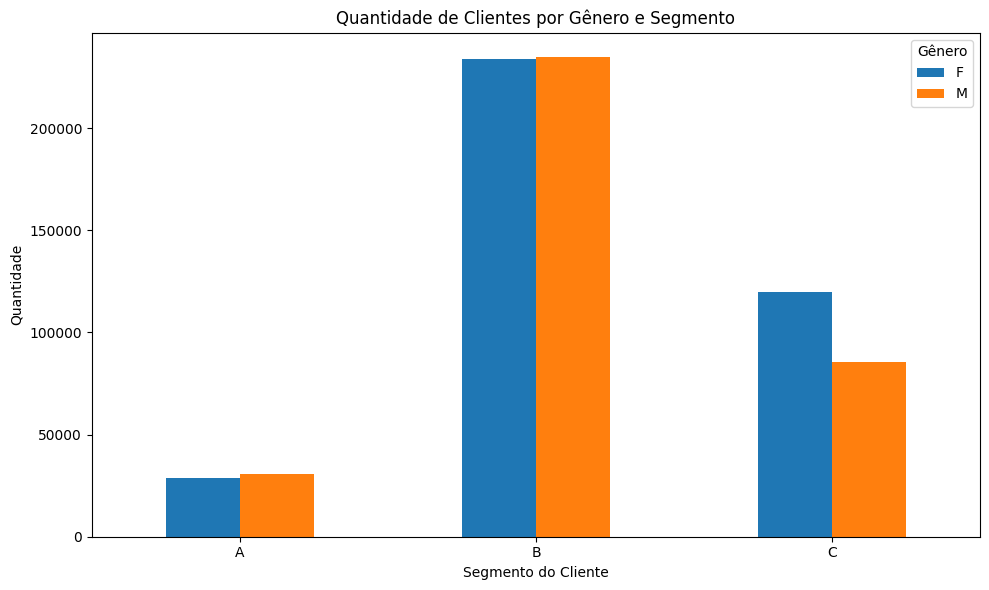

In [ ]:
#Critério de avaliação do tipo: Padrões de Agrupamento.
#Agrupamento 1: Um agrupamento por gênero (CL_GENERO) e segmento (CL_SEG) para identificar a quantidade de clientes em cada grupo.
#Conto quantos clientes existem por gênero e segmento, e transformo a tabela para formato de gráfico e visualização dos dados.
import matplotlib.pyplot as plt

# Transforma os dados para o formato do gráfico
grafico = genero_segmento.pivot(
    index='CL_SEG',
    columns='CL_GENERO',
    values='Quantidade'
)

# Gráfico de barras agrupadas
grafico.plot(kind='bar', figsize=(10, 6))

plt.title('Quantidade de Clientes por Gênero e Segmento')
plt.xlabel('Segmento do Cliente')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.legend(title='Gênero')
plt.tight_layout()

plt.show()

In [ ]:

#Critério de avaliação do tipo: Padrões de Agrupamento.
#Agrupamento 2: Quantidade de compras por categoria, gênero e estado civil.
#Entendo como o comportamento de compra varia de acordo com o tipo de produto, gênero do cliente e estado civil.
tipo de produto
gênero do cliente
estado civil
agrupamento = (
    df.groupby(['PR_CAT', 'CL_GENERO', 'CL_EC'])
      .size()
      .reset_index(name='Quantidade')
)

display(agrupamento)

,PR_CAT,CL_GENERO,CL_EC,Quantidade
0,ACESSORIOS,F,1,1396
1,ACESSORIOS,F,2,1580
2,ACESSORIOS,F,3,1813
3,ACESSORIOS,F,4,1817
4,ACESSORIOS,F,5,233
...,...,...,...,...
65,SEM CATEGORIA,M,1,415
66,SEM CATEGORIA,M,2,388
67,SEM CATEGORIA,M,3,372
68,SEM CATEGORIA,M,4,335


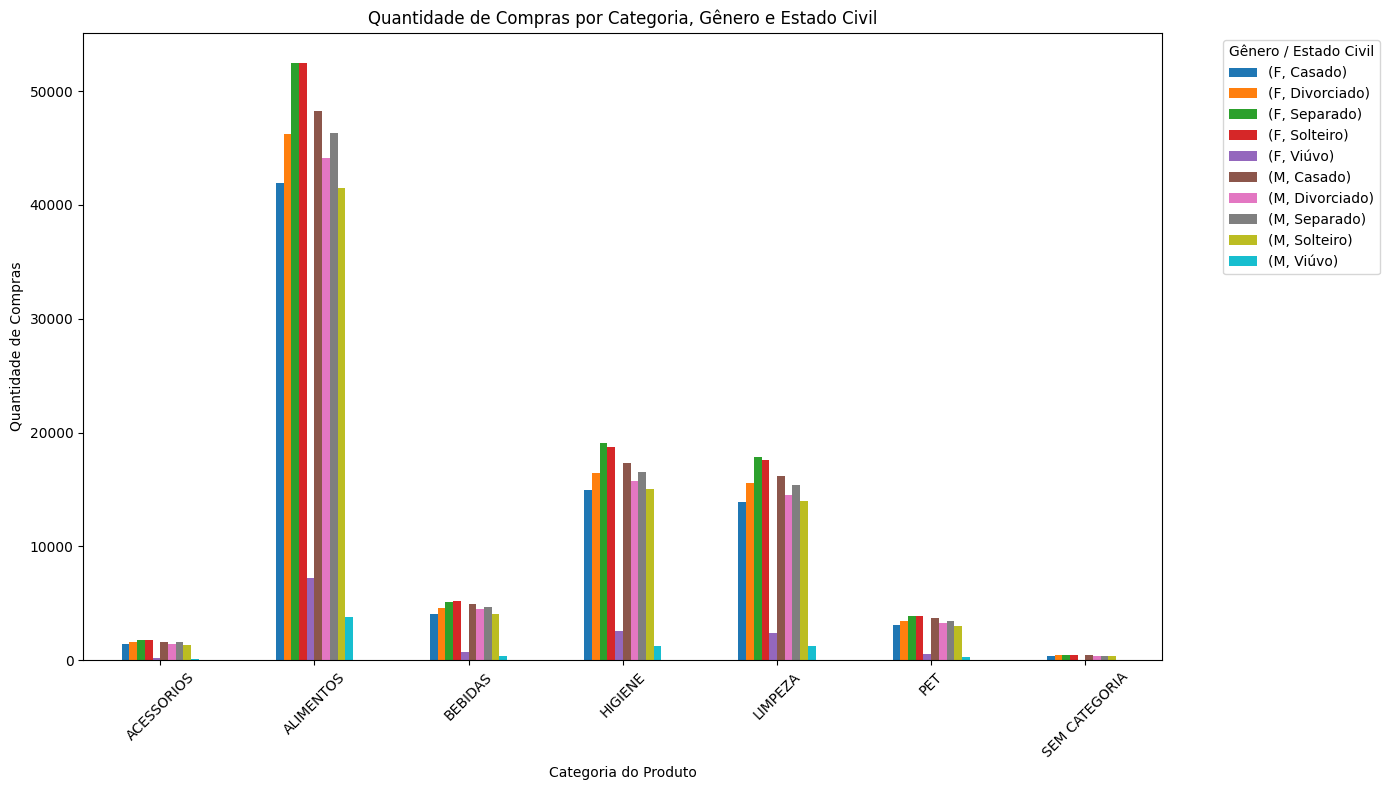

In [ ]:


#Critério de avaliação do tipo: Padrões de Agrupamento.
#Agrupamento 2: Quantidade de compras por categoria, gênero e estado civil.
#Transformo códigos de estado civil em nomes, conto a quantidade de compras por categoria, gênero e estado civil, organizo os dados em formato de tabela e gero um gráfico de barras para visualizar os padrões de consumo.

# Traduzir estado civil
estado_civil = {
    1: 'Casado',
    2: 'Divorciado',
    3: 'Separado',
    4: 'Solteiro',
    5: 'Viúvo'
}

df['CL_EC_DESC'] = df['CL_EC'].map(estado_civil)

# Agrupamento
agrupamento = (
    df.groupby(['PR_CAT', 'CL_GENERO', 'CL_EC_DESC'])
      .size()
      .reset_index(name='Quantidade')
)

# Tabela dinâmica para o gráfico
pivot = agrupamento.pivot_table(
    index='PR_CAT',
    columns=['CL_GENERO', 'CL_EC_DESC'],
    values='Quantidade',
    fill_value=0
)

# Gráfico de barras agrupadas
pivot.plot(
    kind='bar',
    figsize=(14, 8)
)

plt.title('Quantidade de Compras por Categoria, Gênero e Estado Civil')
plt.xlabel('Categoria do Produto')
plt.ylabel('Quantidade de Compras')
plt.xticks(rotation=45)
plt.legend(
    title='Gênero / Estado Civil',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()

plt.show()